In [1]:
import pandas as pd
import numpy as np
from tslearn.clustering import TimeSeriesKMeans
import matplotlib.pyplot as plt
from utils import *
import math
from matplotlib import pyplot as plt
from matplotlib_venn import venn2, venn3
import re


In [5]:
df_1_hME1_scaled = pd.read_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled_phPlus_localized.xlsx")
df_1_hME1_scaled = df_1_hME1_scaled.fillna(0)

df_2_hME1_scaled = pd.read_excel("Experiment/2_hTERT_HME1/Data/Processed/Full_dataset_2_hTERT_HME1_functional_names_diff_scaled_phPlus.xlsx")
df_2_hME1_scaled = df_2_hME1_scaled.fillna(0)

df_1_HEK_scaled = pd.read_excel("Experiment/1_HEK293T/Data/Processed/Full_dataset_HEK293T_functional_names_diff_scaled_phPlus.xlsx")
df_1_HEK_scaled = df_1_HEK_scaled.fillna(0)

In [43]:
df_1_hME1_scaled

,protein_Id,protein_name,site,raw_abs_EGF_full_r1,raw_abs_EGF_full_r2,raw_abs_EGF_full_r3,raw_abs_EGF_full_r4,raw_abs_EGF_starve_r1,raw_abs_EGF_starve_r2,raw_abs_EGF_starve_r3,...,FC_scaled_EGFnINS_1,FC_scaled_EGFnINS_2,FC_scaled_EGFnINS_5,FC_scaled_EGFnINS_10,FC_scaled_EGFnINS_90,phospho_sites,functional_score,ms_lit,ERK_motif,ERK_ext_motif
0,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_0~SGSGNFGGGR,0.000000e+00,3.413601e+04,0.000000e+00,0.000000e+00,0.000000,11970.095745,0.000000,...,0.009989,0.027808,0.150342,0.266855,0.384599,0,0.000000,0.0,0.0,0.0
1,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_152_154_1_1_S154~SGsGNFGGGR,2.526291e+06,3.107422e+06,2.844213e+06,2.838165e+06,462877.845884,406460.086218,466606.366000,...,-0.013889,0.076752,0.324961,0.489716,0.582838,S154,0.000000,0.0,0.0,0.0
2,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_0~NQGGYGGSSSSSSYGSGR,2.538396e+05,2.912180e+05,1.878137e+05,2.302995e+05,370294.907420,351169.823470,391574.055743,...,-0.298015,-0.083473,-0.121019,-0.236009,-1.000000,0,0.000000,0.0,0.0,0.0
3,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S264~NQGGYGGSsSSSSYGSGR,0.000000e+00,3.436628e+04,0.000000e+00,3.184211e+04,0.000000,36947.507319,0.000000,...,-0.473961,0.472592,-0.426896,1.000000,-0.556594,S264,0.000000,0.0,0.0,0.0
4,A0A2R8Y4L2,HNRNPA1L3,A0A2R8Y4L2_260_271_1_1_S266~NQGGYGGSSSsSSYGSGR,4.004880e+05,5.070251e+05,2.948686e+05,0.000000e+00,732858.964004,703950.993495,706990.737660,...,-0.433320,-0.418878,-0.566253,-0.678022,-0.971486,S266,0.000000,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34997,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_338_1_1_S338~SLsFEMQQDELIEK,3.612031e+04,3.523211e+04,2.328310e+04,2.882678e+04,28158.918559,31337.999945,38445.424548,...,0.339692,-0.197463,0.293183,0.357531,0.632659,S338,0.588318,18.0,0.0,0.0
34998,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_356_1_0~SLSFEMQQDELIEKPMSPMQYAR,0.000000e+00,0.000000e+00,0.000000e+00,1.989511e+04,0.000000,0.000000,0.000000,...,-0.677587,0.251546,-0.903483,-0.073504,-0.696452,0,0.000000,0.0,0.0,0.0
34999,Q9Y6Y0,IVNS1ABP,Q9Y6Y0_336_356_1_1_S338~SLsFEMQQDELIEKPMSPMQYAR,2.252726e+05,2.548493e+05,1.697470e+05,1.780225e+05,202512.144807,165807.326109,237987.604392,...,0.341903,0.492076,0.097209,0.917837,0.303394,S338,0.588318,18.0,0.0,0.0
35000,Q9Y6Y8,SEC23IP,Q9Y6Y8_118_138_1_0~PLTALPFTTGSQDVSNAFSPSISK,0.000000e+00,0.000000e+00,3.689021e+03,0.000000e+00,0.000000,0.000000,5253.875296,...,-1.000000,0.300186,0.197979,0.221990,-0.289061,0,0.000000,0.0,0.0,0.0


# Venn diagrams - sites
Venn diagrams for all the sites without any kind of filtering

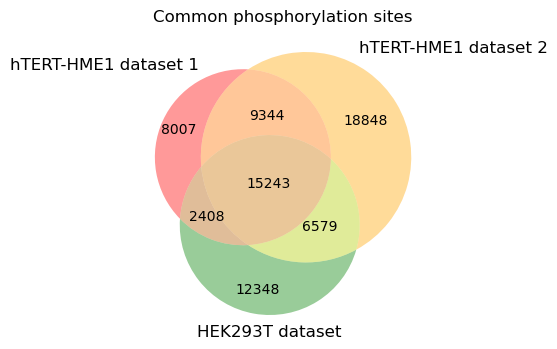

hTERT-HME1 dataset 1 localized sites: 35002
hTERT-HME1 dataset 2 localized sites: 50014
HEK293T dataset 1 localized sites: 36578


In [43]:
HME1_1_sites = set(df_1_hME1_scaled.site.unique().tolist())
HME1_2_sites = set(df_2_hME1_scaled.site.unique().tolist())
HEK_sites = set(df_1_HEK_scaled.site.unique().tolist())

plt.figure(figsize=(6, 4))
venn3([HME1_1_sites, HME1_2_sites, HEK_sites], set_labels=(f"hTERT-HME1 dataset 1", f"hTERT-HME1 dataset 2", f"HEK293T dataset"), set_colors=("red", "orange", "green"))
plt.title("Common phosphorylation sites")
plt.show()
print(f"hTERT-HME1 dataset 1 localized sites: {len(df_1_hME1_scaled)}")
print(f"hTERT-HME1 dataset 2 localized sites: {len(df_2_hME1_scaled)}")
print(f"HEK293T dataset 1 localized sites: {len(df_1_HEK_scaled)}")


common_sites = HME1_1_sites & HME1_2_sites & HEK_sites


# Venn diagrams - localized sites

In [32]:
# df_1_hME1_scaled['localized_sites'] = df_1_hME1_scaled['site'].apply(
#     lambda x: re.split(r'_|\~', str(x))[4] if len(re.split(r'_|\~', str(x))) > 4 else None
# )
# col = df_1_hME1_scaled.pop("localized_sites")
# df_1_hME1_scaled.insert(3, 'localized_sites', col)
# df_1_hME1_scaled['localized_sites'] = df_1_hME1_scaled['localized_sites'].astype(int)
# reps = df_1_hME1_scaled.pop("n_rep")
# df_1_hME1_scaled.insert(4, "n_rep", reps)
# df_1_hME1_scaled.to_excel("Experiment/1_hTERT_HME1/Data/Processed/Full_dataset_1_hTERT_HME1_functional_names_diff_scaled_phPlus_localized.xlsx", index=False)

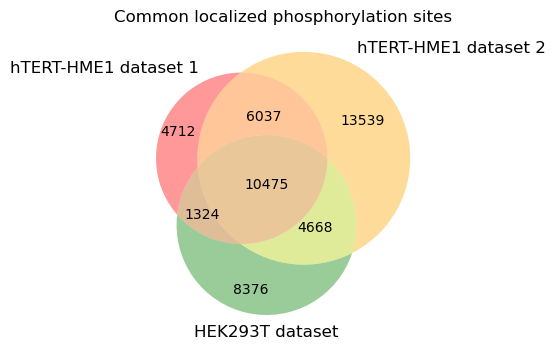

hTERT-HME1 dataset 1 localized sites: 22548
hTERT-HME1 dataset 2 localized sites: 34719
HEK293T dataset 1 localized sites: 24843


In [39]:
df_1_hME1_localized = df_1_hME1_scaled.loc[df_1_hME1_scaled["localized_sites"] > 0]
df_2_hME1_localized = df_2_hME1_scaled.loc[df_2_hME1_scaled["localized_sites"] > 0]
df_1_HEK_localized = df_1_HEK_scaled.loc[df_1_HEK_scaled["localized_sites"] > 0]

HME1_1_loc_sites = set(df_1_hME1_localized.site.unique().tolist())
HME1_2_loc_sites = set(df_2_hME1_localized.site.unique().tolist())
HEK_loc_sites = set(df_1_HEK_localized.site.unique().tolist())

plt.figure(figsize=(6, 4))
venn3([HME1_1_loc_sites, HME1_2_loc_sites, HEK_loc_sites], set_labels=(f"hTERT-HME1 dataset 1", f"hTERT-HME1 dataset 2", f"HEK293T dataset"), set_colors=("red", "orange", "green"))
plt.title("Common localized phosphorylation sites")
plt.show()
print(f"hTERT-HME1 dataset 1 localized sites: {len(df_1_hME1_localized)}")
print(f"hTERT-HME1 dataset 2 localized sites: {len(df_2_hME1_localized)}")
print(f"HEK293T dataset 1 localized sites: {len(df_1_HEK_localized)}")


In [42]:
common_localized_sites = HME1_1_loc_sites & HME1_2_loc_sites & HEK_loc_sites
print (len(common_localized_sites))

10475


# Venn diagrams - localized sites, n_rep > 1


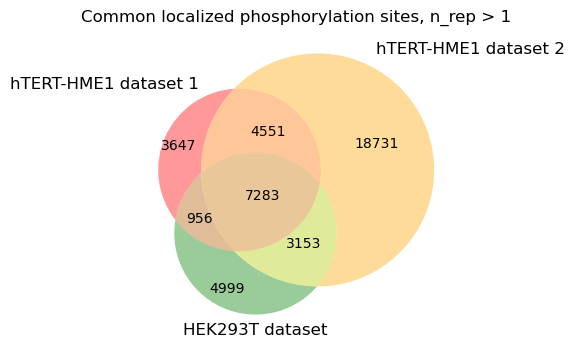

hTERT-HME1 dataset 1 localized sites, n_rep > 1: 16437
hTERT-HME1 dataset 2 localized sites, n_rep > 1: 33718
HEK293T dataset 1 localized sites, n_rep > 1: 16391


In [44]:
df_1_hME1_localized = df_1_hME1_scaled.loc[df_1_hME1_scaled["localized_sites"] > 0]
df_2_hME1_localized = df_2_hME1_scaled.loc[df_2_hME1_scaled["localized_sites"] > 0]
df_1_HEK_localized = df_1_HEK_scaled.loc[df_1_HEK_scaled["localized_sites"] > 0]

df_1_hME1_loc_rep234 = df_1_hME1_localized.loc[df_1_hME1_localized["n_rep"] > 1]
df_2_hME1_loc_rep234 = df_2_hME1_scaled.loc[df_2_hME1_scaled["n_rep"] > 1]
df_1_HEK_loc_rep234 = df_1_HEK_localized.loc[df_1_HEK_localized["n_rep"] > 1]

HME1_1_loc_rep234 = set(df_1_hME1_loc_rep234.site.unique().tolist())
HME1_2_loc_rep234 = set(df_2_hME1_loc_rep234.site.unique().tolist())
HEK_loc_rep234 = set(df_1_HEK_loc_rep234.site.unique().tolist())

plt.figure(figsize=(6, 4))
venn3([HME1_1_loc_rep234, HME1_2_loc_rep234, HEK_loc_rep234], set_labels=(f"hTERT-HME1 dataset 1", f"hTERT-HME1 dataset 2", f"HEK293T dataset"), set_colors=("red", "orange", "green"))
plt.title("Common localized phosphorylation sites, n_rep > 1")
plt.show()
print(f"hTERT-HME1 dataset 1 localized sites, n_rep > 1: {len(HME1_1_loc_rep234)}")
print(f"hTERT-HME1 dataset 2 localized sites, n_rep > 1: {len(HME1_2_loc_rep234)}")
print(f"HEK293T dataset 1 localized sites, n_rep > 1: {len(HEK_loc_rep234)}")


In [ ]:
common_localized_sites_nrep234 = HME1_1_loc_rep234 & HME1_2_loc_rep234 & HEK_loc_rep234
print (len(common_localized_sites_nrep234))